In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "-q", "install",
                "datasets>=3.0", "huggingface_hub>=0.24", "transformers>=4.45",
                "Pillow", "matplotlib", "pandas", "numpy", "sympy",
                "accelerate", "tqdm"], check=True)

import os, re, io, json, math, random, textwrap, hashlib, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import sympy as sp
from datasets import load_dataset
warnings.filterwarnings("ignore")
random.seed(0); np.random.seed(0)
pd.set_option("display.max_colwidth", 120)

DS_ID = "TuringEnterprises/Open-MM-RL"
ds = load_dataset(DS_ID, split="train")
print(f"Loaded {DS_ID} — {len(ds)} rows")
print("Features:", ds.features)
print("Row 0 keys:", list(ds[0].keys()))

In [ ]:
df = ds.remove_columns(["images"]).to_pandas()
df["n_images"]    = [len(ex["images"]) for ex in ds]
df["q_len_chars"] = df["question"].str.len()
df["a_len_chars"] = df["answer"].str.len()

print("\n=== Domain ==="); print(df["domain"].value_counts())
print("\n=== Format ==="); print(df["format"].value_counts())
print("\n=== Sub-domain (top by domain) ===")
print(df.groupby("domain")["subDomain"].value_counts().head(15))
print(f"\nMean images/example: {df['n_images'].mean():.2f}   max: {df['n_images'].max()}")
print(f"Median Q length: {df['q_len_chars'].median():.0f}   "
      f"Median A length: {df['a_len_chars'].median():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["domain"].value_counts().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Examples per domain"); axes[0].set_ylabel("count")
df["format"].value_counts().plot.bar(ax=axes[1], color="#55A868")
axes[1].set_title("Image-format type"); axes[1].tick_params(axis='x', rotation=25)
df["n_images"].plot.hist(ax=axes[2], bins=range(1, df["n_images"].max() + 2),
                         color="#C44E52", edgecolor="white")
axes[2].set_title("Images per example"); axes[2].set_xlabel("n_images")
plt.tight_layout(); plt.show()

def img_stats(ex):
    sizes = [im.size for im in ex["images"]]
    modes = [im.mode for im in ex["images"]]
    return {
        "n_images": len(sizes),
        "min_w": min(w for w, h in sizes), "max_w": max(w for w, h in sizes),
        "min_h": min(h for w, h in sizes), "max_h": max(h for w, h in sizes),
        "modes": "|".join(sorted(set(modes))),
        "total_pixels": sum(w * h for w, h in sizes),
    }
img_df = pd.DataFrame([img_stats(ex) for ex in ds])
print("\n=== Image resolution stats ===")
print(img_df[["min_w", "max_w", "min_h", "max_h", "total_pixels"]].describe().round(0))
print("\nMode mix:", Counter("|".join(img_df["modes"]).split("|")))

In [ ]:
def show_example(ex, max_chars=600):
    print("=" * 80)
    print(f"id={ex['conversation_id']}   {ex['domain']} / {ex['subDomain']}")
    print(f"format={ex['format']}   n_images={len(ex['images'])}")
    print("-" * 80)
    q = ex["question"][:max_chars] + ("..." if len(ex["question"]) > max_chars else "")
    print("Q:", textwrap.fill(q, 100))
    print("-" * 80)
    print("A (gold):", ex["answer"])
    n = len(ex["images"])
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5)) if n > 1 \
                else plt.subplots(1, 1, figsize=(6, 6))
    axes = np.atleast_1d(axes)
    for ax, im in zip(axes, ex["images"]):
        ax.imshow(im); ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"{im.size[0]}×{im.size[1]}  ({im.mode})")
    plt.tight_layout(); plt.show()

for dom in df["domain"].unique():
    idx = int(df[df["domain"] == dom].index[0])
    show_example(ds[idx])

LATEX_PAT = re.compile(r"\\\[[\s\S]+?\\\]|\\\([\s\S]+?\\\)|\$[^$]+\$")
df["latex_blocks_q"] = df["question"].apply(lambda s: len(LATEX_PAT.findall(s or "")))
df["latex_blocks_a"] = df["answer"].apply(lambda s: len(LATEX_PAT.findall(s or "")))
print("\n=== LaTeX blocks per field ===")
print(df[["latex_blocks_q", "latex_blocks_a"]].describe().round(2))

def classify_answer(a):
    s = (a or "").strip().strip("$ []").strip()
    s_no_dollar = s.replace("$", "")
    if re.fullmatch(r"-?\s*\d+(\.\d+)?\s*", s_no_dollar):       return "integer/float"
    if any(t in s for t in ["\\sqrt", "\\frac", "\\pi", "^", "_", "\\kappa", "\\lceil"]):
        return "symbolic"
    if re.fullmatch(r"[-+0-9./()\s\\a-zA-Z{}]+", s) and any(c.isdigit() for c in s):
        return "numeric_expr"
    return "text"

df["answer_type"] = df["answer"].apply(classify_answer)
print("\n=== Answer-type breakdown ==="); print(df["answer_type"].value_counts())
print("\n=== Answer-type × domain ===")
print(pd.crosstab(df["domain"], df["answer_type"]))

In [ ]:
EXTRACT_PATS = [
    r"\\boxed\{([^{}]+)\}",
    r"final\s+answer\s*[:=]\s*([^\n]+)",
    r"answer\s*[:=]\s*([^\n]+)",
]
def extract_final(text):
    if not text: return ""
    for p in EXTRACT_PATS:
        m = re.search(p, text, flags=re.IGNORECASE)
        if m: return m.group(1).strip().strip(".,;")
    lines = [l.strip() for l in str(text).strip().splitlines() if l.strip()]
    return lines[-1] if lines else ""

def latex_to_sympy(s):
    s = (s or "").strip().strip("$").strip()
    s = re.sub(r"^\\[\[\(]", "", s); s = re.sub(r"\\[\]\)]$", "", s)
    s = (s.replace("\\pi", "pi").replace("\\cdot", "*").replace("\\times", "*")
           .replace("\\,", "").replace("\\;", "").replace("\\!", ""))
    s = re.sub(r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}", r"((\1)/(\2))", s)
    s = re.sub(r"\\sqrt\s*\{([^{}]+)\}", r"sqrt(\1)", s)
    s = s.replace("^", "**")
    s = re.sub(r"\\[a-zA-Z]+", "", s)
    s = s.replace("{", "(").replace("}", ")")
    return s

def grade(pred, gold, tol=1e-4):
    """Verifiable reward in [0,1]: exact > numeric > sympy-symbolic > partial."""
    if pred is None or gold is None: return 0.0
    p = extract_final(str(pred)).strip()
    g = str(gold).strip()
    norm = lambda x: re.sub(r"\s+", "", x.lower()).strip("$.,;[]()")
    if norm(p) == norm(g): return 1.0
    def to_float(x):
        try: return float(latex_to_sympy(x))
        except Exception:
            try: return float(sp.sympify(latex_to_sympy(x)).evalf())
            except Exception: return None
    fp, fg = to_float(p), to_float(g)
    if fp is not None and fg is not None:
        if abs(fp - fg) / max(1.0, abs(fg)) < tol: return 1.0
    try:
        ep = sp.sympify(latex_to_sympy(p)); eg = sp.sympify(latex_to_sympy(g))
        if sp.simplify(ep - eg) == 0: return 1.0
    except Exception:
        pass
    if norm(g) and norm(g) in norm(p): return 0.5
    return 0.0

print("\n=== Grader sanity checks ===")
for pred, gold, want in [
    ("The answer is \\boxed{120}",            "[120]",            1.0),
    ("After computing: 7396 \\pi",            "7396\\pi",         1.0),
    ("Final answer: -71/4",                   "-\\frac{71}{4}",   1.0),
    ("Therefore the result is 0.0074",        "0.0074",           1.0),
    ("Final answer: nucleus accumbens",       "Nucleus accumbens",1.0),
    ("I don't know",                          "12",               0.0),
]:
    print(f"  pred={pred[:38]!r:42s} gold={gold!r:22s} -> r={grade(pred, gold)}  (want {want})")

SYSTEM = ("You are a STEM expert solving multimodal reasoning problems. "
          "You will see a question and one or more figures. "
          "Reason step by step, then end with exactly one line:\n"
          "Final answer: <your answer>")

def build_prompt(ex):
    img_tags = "\n".join(f"[Image {i+1}]" for i in range(len(ex["images"])))
    return f"{SYSTEM}\n\n{img_tags}\n\nQuestion:\n{ex['question']}\n\nLet's think step by step."

print("\n=== Example prompt (truncated) ===")
print(build_prompt(ds[0])[:600], "...\n")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40 [00:00<?, ? examples/s]

Loaded TuringEnterprises/Open-MM-RL — 40 rows
Features: {'conversation_id': Value('string'), 'domain': Value('string'), 'subDomain': Value('string'), 'author_id': Value('string'), 'question': Value('string'), 'answer': Value('string'), 'format': Value('string'), 'images': List(Image(mode=None, decode=True))}
Row 0 keys: ['conversation_id', 'domain', 'subDomain', 'author_id', 'question', 'answer', 'format', 'images']

=== Domain ===
domain
Biology      11
Chemistry    10
Physics      10
Math          9
Name: count, dtype: int64

=== Format ===
format
multi_image     19
single_image    11
multi_panel     10
Name: count, dtype: int64

=== Sub-domain (top by domain) ===
domain     subDomain                     
Biology    Molecular Biology                 5
           Neurobiology                      3
           Evolutionary Biology              2
           Cell biology                      1
Chemistry  Inorganic Chemistry               5
           Organic Chemistry                 4
 

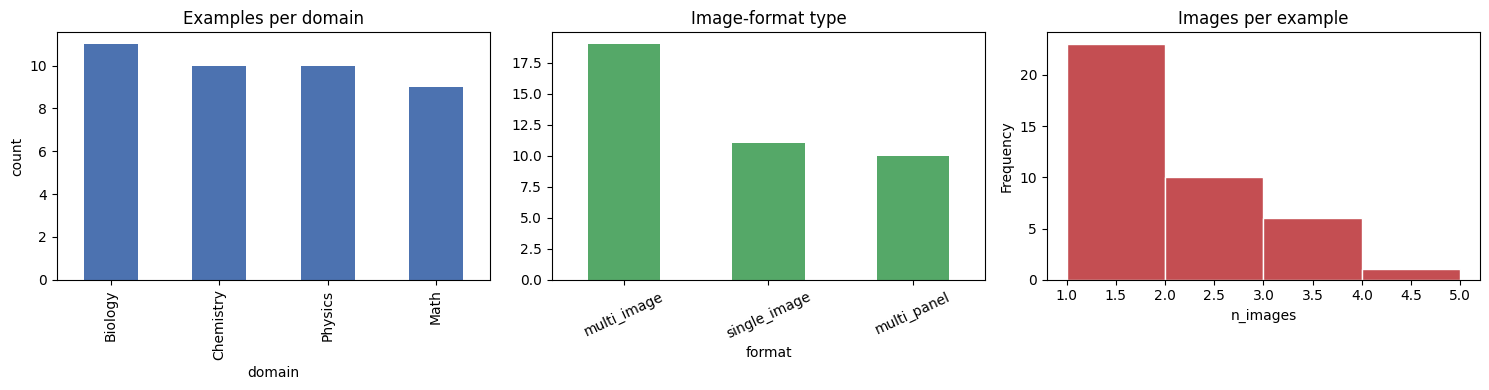


=== Image resolution stats ===
        min_w   max_w   min_h   max_h  total_pixels
count    40.0    40.0    40.0    40.0          40.0
mean    971.0  1060.0   667.0   728.0     1372535.0
std     655.0   651.0   485.0   537.0     1759790.0
min     265.0   317.0   118.0   157.0       49769.0
25%     558.0   645.0   334.0   392.0      366704.0
50%     792.0   811.0   508.0   556.0      613364.0
75%    1168.0  1274.0   827.0   846.0     1512795.0
max    3200.0  3200.0  2268.0  2466.0     7390413.0

Mode mix: Counter({'RGBA': 29, 'RGB': 11, 'P': 1})
id=306510   Math / Field theory and polynomials
format=multi_panel   n_images=1
--------------------------------------------------------------------------------
Q: Determine the number of monic primitive irreducible polynomials of degree \[
d=11ci^{+e}_{2r}(G_4)+ci^{+e}_{2r}(G_1)+ci^{v}_{2r}(G_3)+ci^{+e}_{2r}(G_2)+ci^{-e}_{2r}(G_3) \] over
the finite field \[ \mathbb F_q, \] where \[
q=2^{ci^{+e}_{2r}(G_1)+ci^{v}_{2r}(G_3)-ci^{+e}_{2r}(G_2)-ci^

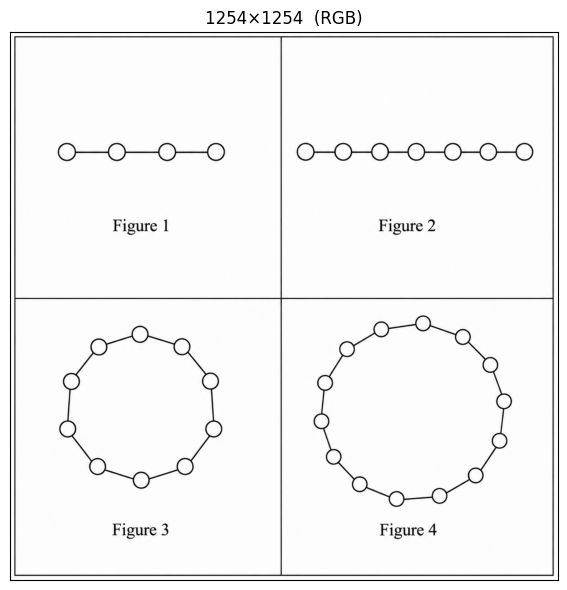

id=306296   Biology / Neurobiology
format=single_image   n_images=1
--------------------------------------------------------------------------------
Q: In this multi-compartment model of leech T-cells, different spike initiation zone (SIZ)
distributions are tested on reconstructed morphologies while holding ion channel parameters fixed.
Using the Figure $1$, identify which SIZ placement produces the second lowest height across the
reconstructed morphologies?
--------------------------------------------------------------------------------
A (gold): Anterior


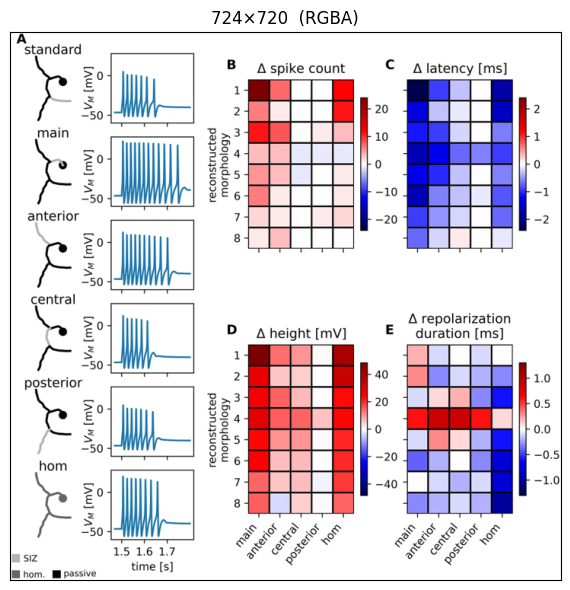

id=306136   Chemistry / Organic Chemistry
format=multi_image   n_images=2
--------------------------------------------------------------------------------
Q: Based on the attached images, please identify the IUPAC name of the final compound.
--------------------------------------------------------------------------------
A (gold): 3-bromo-12-(2-methoxyphenyl)-10,12-dihydro-11H-benzo[5,6]chromeno[2,3-d]pyrimidin-11-one


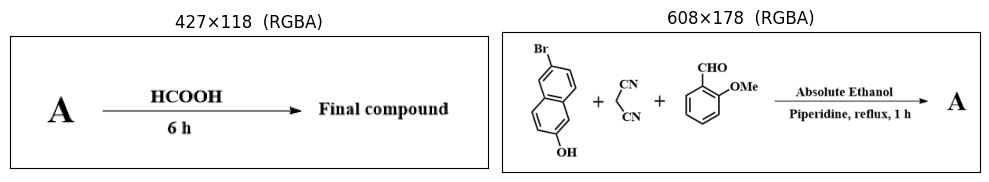

id=305996   Physics / High-energy particle physics
format=multi_image   n_images=4
--------------------------------------------------------------------------------
Q:  Using the physical mechanisms and parameter-space structures illustrated by Fig. 1,  Fig. 2, Fig.
3, and  Fig. 4.  Work in the TS5 heavy-light regime with \[ M_{G^*}=1.5~\text{TeV},\qquad
m_T=m_B=m_{\tilde T}=m_{\tilde B}=1.0~\text{TeV}, \] \[ Y_*=3,\qquad m_t=173~\text{GeV},\qquad
v=246~\text{GeV}, \] and impose \[ s_{b_R}=s_L,\qquad c_i\equiv \sqrt{1-s_i^2},\qquad \tau\equiv
\tan\theta_3. \]  The physical heavy gluon is obtained from elementary/composite mixing, \[ G=c_3
G_{\rm el}+s_3 G_{\rm comp},\qquad G^*=-s_3 G_{\rm el}+c_3 G_{\rm comp}, \] with \(\tau=s_3/c_3\),
and the light/heavy fe...
--------------------------------------------------------------------------------
A (gold): \[1.172\times 10^{-2}
\]


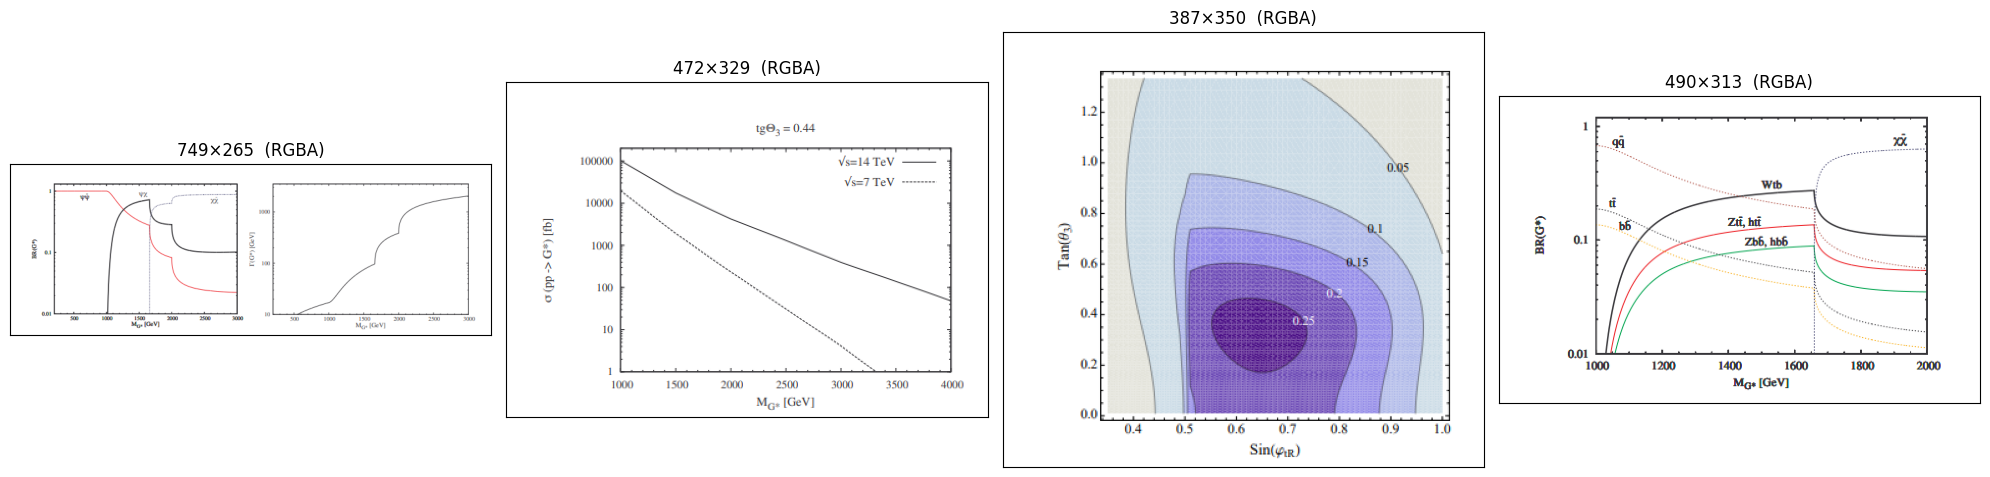


=== LaTeX blocks per field ===
       latex_blocks_q  latex_blocks_a
count           40.00           40.00
mean            12.60            0.72
std             15.55            0.55
min              0.00            0.00
25%              2.00            0.00
50%              6.50            1.00
75%             20.25            1.00
max             76.00            2.00

=== Answer-type breakdown ===
answer_type
text             22
symbolic         11
integer/float     6
numeric_expr      1
Name: count, dtype: int64

=== Answer-type × domain ===
answer_type  integer/float  numeric_expr  symbolic  text
domain                                                  
Biology                  0             1         0    10
Chemistry                4             0         2     4
Math                     0             0         4     5
Physics                  2             0         5     3

=== Grader sanity checks ===
  pred='The answer is \\boxed{120}'               gold='[120]'             

In [1]:
import torch
USE_VLM = torch.cuda.is_available()
print(f"CUDA available: {USE_VLM}")
if USE_VLM:
    try:
        from transformers import AutoProcessor, AutoModelForVision2Seq
        MODEL_ID = "HuggingFaceTB/SmolVLM-Instruct"
        print(f"Loading {MODEL_ID} (this takes ~1 min) ...")
        processor = AutoProcessor.from_pretrained(MODEL_ID)
        model = AutoModelForVision2Seq.from_pretrained(
            MODEL_ID, torch_dtype=torch.float16, device_map="auto"
        )
        def vlm_solve(ex, max_new_tokens=512):
            imgs = [im.convert("RGB") for im in ex["images"]]
            content = [{"type": "image"} for _ in imgs]
            content.append({"type": "text", "text": build_prompt(ex)})
            text = processor.apply_chat_template(
                [{"role": "user", "content": content}], add_generation_prompt=True)
            inputs = processor(text=text, images=imgs, return_tensors="pt").to(model.device)
            with torch.no_grad():
                out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
            return processor.batch_decode(
                out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]

        rows, sample_idx = [], random.sample(range(len(ds)), 6)
        for i in sample_idx:
            ex = ds[i]
            try:
                pred = vlm_solve(ex)
                r = grade(pred, ex["answer"])
            except Exception as e:
                pred, r = f"<error: {e}>", 0.0
            rows.append({"id": ex["conversation_id"], "domain": ex["domain"],
                         "reward": r, "pred_tail": pred[-200:]})
            print(f"  id={ex['conversation_id']}  {ex['domain']:9s}  r={r:.2f}")
        res = pd.DataFrame(rows)
        print(f"\nMean reward over {len(res)} samples: {res['reward'].mean():.3f}")
        print(res.groupby("domain")["reward"].mean().rename("avg_reward"))
    except Exception as e:
        print(f"VLM run failed ({e}); reward & data pipeline remain usable.")
else:
    print("No GPU detected — skipping live VLM inference (Runtime → Change runtime type → GPU).")

out_dir = Path("/content/open_mm_rl_processed"); out_dir.mkdir(exist_ok=True, parents=True)
img_dir = out_dir / "images"; img_dir.mkdir(exist_ok=True)

records = []
for ex in ds:
    paths = []
    for j, im in enumerate(ex["images"]):
        p = img_dir / f"{ex['conversation_id']}_{j}.png"
        im.convert("RGB").save(p)
        paths.append(str(p))
    records.append({
        "id":         ex["conversation_id"],
        "domain":     ex["domain"],
        "subDomain":  ex["subDomain"],
        "format":     ex["format"],
        "prompt":     build_prompt(ex),
        "gold":       ex["answer"],
        "image_paths": paths,
    })

jsonl_path = out_dir / "data.jsonl"
with open(jsonl_path, "w") as f:
    for r in records: f.write(json.dumps(r) + "\n")
print(f"\nWrote {len(records)} records → {jsonl_path}")
print(f"Saved {sum(len(r['image_paths']) for r in records)} images under {img_dir}")

def mock_policy_samples(gold, K=4):
    """Stand-in for K policy rollouts. Replace with model.generate(do_sample=True)."""
    return [gold,
            "Final answer: 0",
            f"Final answer: {gold} (≈)",
            "I think the answer is unclear."][:K]

def grpo_advantages(rewards):
    r = np.asarray(rewards, dtype=float)
    return (r - r.mean()) / (r.std() + 1e-6)

print("\n=== Mock GRPO rollouts for example 0 ===")
gold0 = ds[0]["answer"]
cands = mock_policy_samples(gold0, K=4)
rewards = [grade(c, gold0) for c in cands]
adv = grpo_advantages(rewards)
for c, r, a in zip(cands, rewards, adv):
    print(f"  r={r:.2f}  adv={a:+.2f}   cand={c!r}")

print("\nDone. To turn this into real training:")
print("  1. Replace mock_policy_samples with vlm_solve(..., do_sample=True, num_return_sequences=K).")
print("  2. Feed (prompt, K rollouts, K rewards) into TRL's GRPOTrainer or verl.")
print("  3. Curriculum: start with examples where rewards have non-zero variance.")